### Setup Environment

In [1]:
!git clone https://github.com/NhuGiap04/Fk-Diffusion-Steering.git

Cloning into 'Fk-Diffusion-Steering'...
remote: Enumerating objects: 243, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 243 (delta 48), reused 43 (delta 35), pack-reused 163 (from 2)
Receiving objects: 100% (243/243), 130.44 MiB | 14.73 MiB/s, done.
Resolving deltas: 100% (111/111), done.


In [1]:
%cd Fk-Diffusion-Steering
!git pull

/content/Fk-Diffusion-Steering
Already up to date.


In [2]:
%pip install -r requirements.txt

Obtaining diffusers from git+https://github.com/huggingface/diffusers@af28ae2d5ba0ef80d99fff7859ebea730e1cf3f8#egg=diffusers (from -r requirements.txt (line 15))
  Skipping because already up-to-date.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
Obtaining image_reward from git+https://****@github.com/THUDM/ImageReward.git@2ca71bac4ed86b922fe53ddaec3109fe94d45fd3#egg=image_reward (from -r requirements.txt (line 28))
  Skipping because already up-to-date.
  Preparing metadata (setup.py) ... done
  Using cached https://github.com/openai/CLIP/archive/refs/heads/main.zip
  Preparing metadata (setup.py) ... done
  Building editable for diffusers (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.31.0.dev0-0.editable-py3-none-any.whl size=11256 sha256=e96a42421b14f8eb2df657ae15c6bf2fe08ecc186a18dcc2be885b8

### SDXL Inference

[Errno 2] No such file or directory: 'text_to_image'
/content/Fk-Diffusion-Steering/text_to_image


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

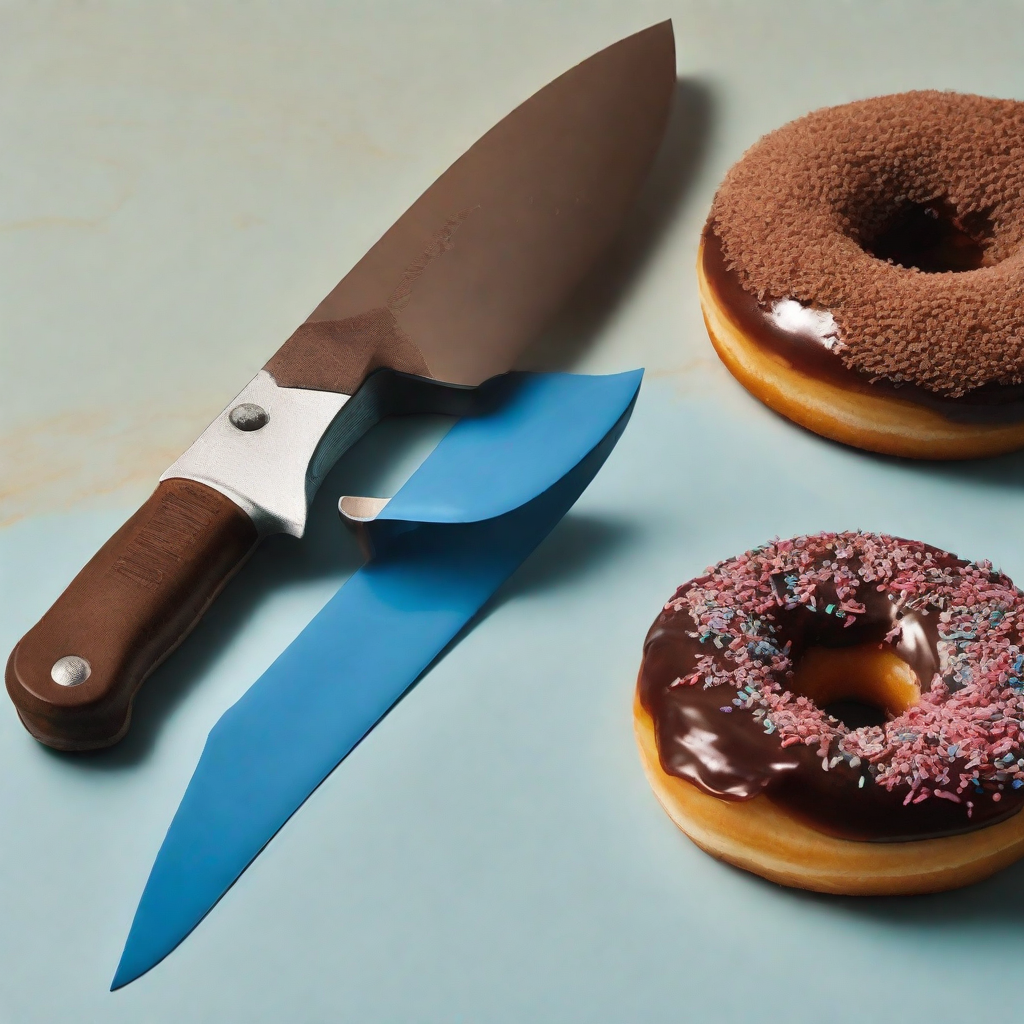

In [5]:
%cd text_to_image

import torch
from diffusers import DDIMScheduler
from IPython.display import display

from XL_diffusers.pipeline_sdxl import OriginalStableDiffusionXL

# 1. Load SDXL base model
pipe = OriginalStableDiffusionXL.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
)

# Optional: match the rest of this repo's common scheduler choice
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

# 2. Move to device
if torch.cuda.is_available():
    pipe = pipe.to("cuda")
else:
    pipe = pipe.to("cpu")

# 3. Generate image(s)
prompt = "a photo of a brown knife and a blue donut"
images = pipe(
    prompt=prompt,
    num_inference_steps=50,
    guidance_scale=5.0,
    num_images_per_prompt=1,
    eta=1.0,
)[0]

# 4. Display result inline
display(images[0])

**Optional**: score generated images with reward utilities

In [6]:
from XL_diffusers.rewards import get_reward_function

scores = get_reward_function(
    reward_name="ImageReward",
    images=images,
    prompts=[prompt] * len(images),
)
print(scores)

`metric_to_chase` will be ignored as it only applies to 'LLMGrader' as the `reward_name`
[0.12455063313245773]
